# FFTバンド帯スペクトルのCNN特徴抽出 → 含水率回帰

`docs/fft_band_stepwise_features.md` の9バンドが参照する帯域(nm)から、
**4チャネルのスペクトル(raw / SNV / SG1 / SG2)** を切り出し、1D-CNN で含水率(MC)を
回帰学習する。学習済みCNNの中間表現(埋め込み)を **MCで色付け可視化** し、さらに
埋め込みを特徴とした複数の機械学習モデルで **LOSO macro-RMSE** を検証する。

- データ: `data/train_clean.csv`(Shift-JIS, 1270本, 13樹種)。波数cm⁻¹降順 → nm昇順に変換。
- 前処理は全て**行単位(リーク無し)**。CNN/MLは**各LOSO foldの学習側でfit**。
- バンドはEDA確定のものを固定使用(`fft_band_stepwise_features.md`準拠)。統計量選択のような
  fold毎再探索リークは無いが、バンド固定自体は楽観側であることに留意([[loso-validation-and-leakage]])。


In [1]:
import numpy as np, pandas as pd, time
import matplotlib, matplotlib.pyplot as plt
import torch, torch.nn as nn
from scipy.signal import savgol_filter
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
matplotlib.rcParams['font.family'] = ['Hiragino Sans','AppleGothic','sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
dev = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', dev, '| torch', torch.__version__)

device: cpu | torch 2.12.0


In [2]:
# --- データ読み込み & nm昇順 ---
tr = pd.read_csv('../data/train_clean.csv', encoding='shift_jis')
META = ['sample number','species number','樹種','含水率']
wn_cols = [c for c in tr.columns if c not in META]
wn = np.array([float(c) for c in wn_cols]); wl = 1e7 / wn         # cm-1 -> nm
order = np.argsort(wl); nm = wl[order]
Xraw = tr[wn_cols].values.astype(float)[:, order]                # 生スペクトル(nm昇順)
mc = tr['含水率'].values.astype(float)
sp = tr['樹種'].values
species = np.unique(sp)
print('train', Xraw.shape, '| nm %.0f-%.0f' % (nm.min(), nm.max()),
      '| MC %.1f-%.1f%%' % (mc.min(), mc.max()), '| 樹種', len(species))

train (1270, 1555) | nm 1001-2500 | MC 0.8-298.6% | 樹種 13


In [3]:
# --- 前処理関数(行単位=リーク無し) ---
def snv(M): return (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-8)
sg  = lambda M, d: savgol_filter(M, 11, 2, deriv=d, axis=1)

# fft_band_stepwise の9バンドが参照する帯域を重複統合した6区間
INTERVALS = [(1050,1300),(1430,1470),(1600,1700),(1910,1940),(2000,2100),(2400,2480)]
bmask = np.zeros(len(nm), bool)
for lo,hi in INTERVALS: bmask |= (nm>=lo)&(nm<=hi)
nm_b = nm[bmask]
print('バンド点数 L =', bmask.sum(), '区間:', INTERVALS)

# 4チャネルを全スペクトルで計算 → バンド区間を切り出し(SG端効果回避のため全幅で微分)
Sx   = Xraw
Ssnv = snv(Xraw)
Ssg1 = sg(Ssnv, 1)
Ssg2 = sg(Ssnv, 2)
CH_NAMES = ['raw','snv','sg1','sg2']
X = np.stack([Sx[:,bmask], Ssnv[:,bmask], Ssg1[:,bmask], Ssg2[:,bmask]], axis=1)  # [N,4,L]
print('CNN入力テンソル X:', X.shape, '(N, ch, L)')

バンド点数 L = 738 区間: [(1050, 1300), (1430, 1470), (1600, 1700), (1910, 1940), (2000, 2100), (2400, 2480)]
CNN入力テンソル X: (1270, 4, 738) (N, ch, L)


In [4]:
# --- 1D-CNN: 多チャネルバンドスペクトル -> 埋め込み -> MC ---
class SpecCNN(nn.Module):
    def __init__(self, in_ch=4, emb=24):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv1d(in_ch,16,7,padding=3), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16,32,5,padding=2),    nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32,64,3,padding=1),    nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1))
        self.emb  = nn.Linear(64, emb)
        self.head = nn.Sequential(nn.ReLU(), nn.Dropout(0.2), nn.Linear(emb,1))
    def forward(self, x):
        h = self.feat(x).squeeze(-1)
        e = self.emb(h)
        return self.head(e).squeeze(-1), e

def fit_cnn(Xtr, ytr, epochs=140, bs=64, lr=1e-3, emb=24, seed=SEED, verbose=False):
    # チャネル毎標準化(train統計) + y標準化で学習。net と scaler群を返す。
    torch.manual_seed(seed); np.random.seed(seed)
    cmu = Xtr.mean((0,2), keepdims=True); csd = Xtr.std((0,2), keepdims=True)+1e-8
    ymu, ysd = ytr.mean(), ytr.std()+1e-8
    Xn = (Xtr-cmu)/csd
    xt = torch.tensor(Xn, dtype=torch.float32, device=dev)
    yt = torch.tensor((ytr-ymu)/ysd, dtype=torch.float32, device=dev)
    net = SpecCNN(in_ch=Xtr.shape[1], emb=emb).to(dev)
    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=1e-4)
    lossf = nn.MSELoss(); n = len(xt)
    net.train()
    for ep in range(epochs):
        perm = torch.randperm(n, device=dev)
        for i in range(0, n, bs):
            idx = perm[i:i+bs]
            opt.zero_grad()
            pred,_ = net(xt[idx]); loss = lossf(pred, yt[idx])
            loss.backward(); opt.step()
        if verbose and (ep+1)%40==0: print(f'  ep{ep+1} loss {loss.item():.3f}')
    net.eval()
    return net, (cmu,csd,ymu,ysd)

@torch.no_grad()
def cnn_apply(net, scal, Xa):
    cmu,csd,ymu,ysd = scal
    xt = torch.tensor((Xa-cmu)/csd, dtype=torch.float32, device=dev)
    pred, emb = net(xt)
    return pred.cpu().numpy()*ysd+ymu, emb.cpu().numpy()
print('SpecCNN 定義OK | パラメータ数', sum(p.numel() for p in SpecCNN().parameters()))

SpecCNN 定義OK | パラメータ数 11073


## 1. 内部表現(埋め込み)の可視化

全データでCNNを学習し、24次元埋め込みを PCA / t-SNE で2次元化して **含水率で色付け**。
※ここは探索的可視化のため全データ学習(楽観的)。性能評価は次節のLOSOで行う。

  ep40 loss 0.085


  ep80 loss 0.068


  ep120 loss 0.047


  ep160 loss 0.050


全データ in-sample R=0.989 RMSE=8.02 | 132.7s


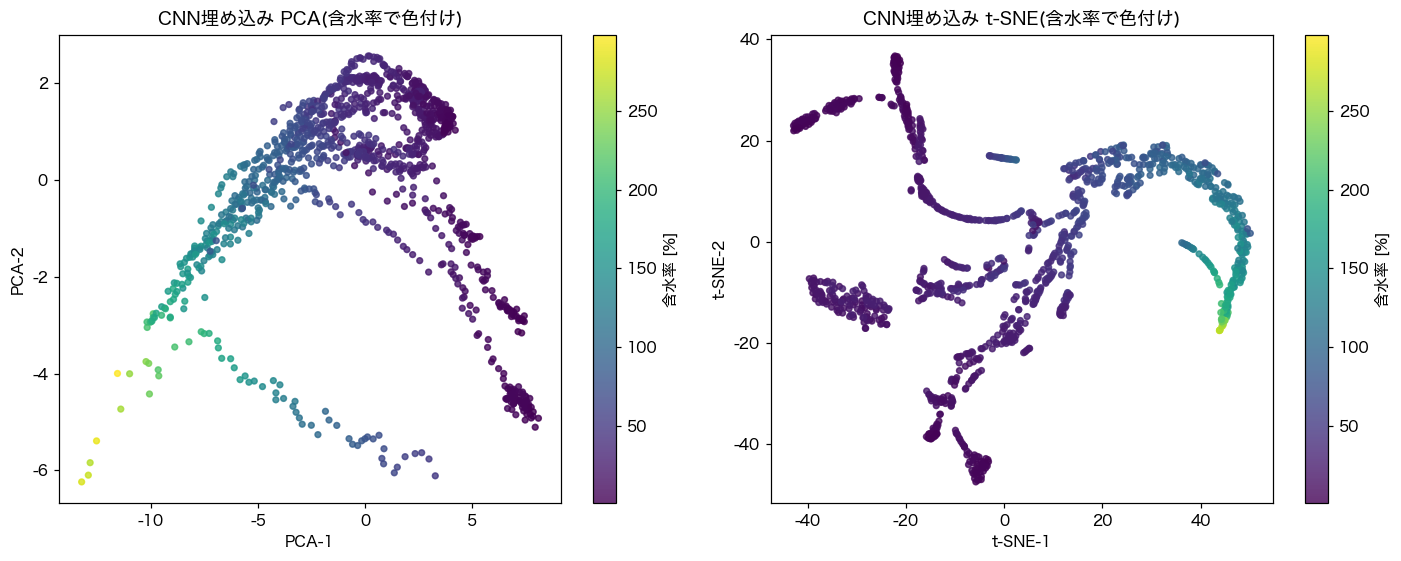

In [5]:
t0=time.time()
net_all, scal_all = fit_cnn(X, mc, epochs=160, verbose=True)
pred_all, emb_all = cnn_apply(net_all, scal_all, X)
from numpy import corrcoef
print('全データ in-sample R=%.3f RMSE=%.2f | %.1fs'
      % (corrcoef(pred_all,mc)[0,1], np.sqrt(((pred_all-mc)**2).mean()), time.time()-t0))

pca = PCA(2).fit_transform(StandardScaler().fit_transform(emb_all))
tsne = TSNE(2, perplexity=30, init='pca', random_state=SEED).fit_transform(emb_all)

fig, ax = plt.subplots(1,2, figsize=(13,5.2))
for a,(Z,t) in zip(ax, [(pca,'PCA'),(tsne,'t-SNE')]):
    s=a.scatter(Z[:,0],Z[:,1],c=mc,cmap='viridis',s=14,alpha=.8)
    a.set_title(f'CNN埋め込み {t}(含水率で色付け)'); a.set_xlabel(f'{t}-1'); a.set_ylabel(f'{t}-2')
    fig.colorbar(s,ax=a,label='含水率 [%]')
plt.tight_layout(); plt.show()

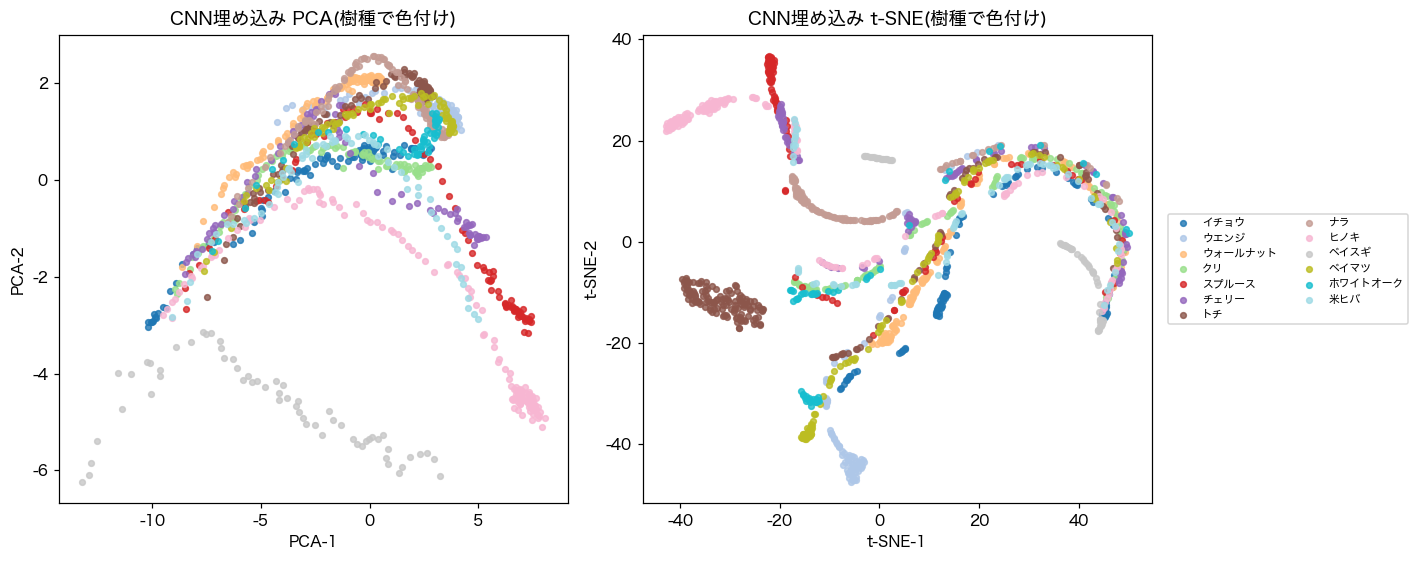

In [6]:
# 樹種別にも色付け(クラスタが樹種に支配されるか確認)
fig, ax = plt.subplots(1,2, figsize=(13,5.2))
cmap = plt.cm.tab20(np.linspace(0,1,len(species)))
for a,(Z,t) in zip(ax,[(pca,'PCA'),(tsne,'t-SNE')]):
    for c,spn in zip(cmap,species):
        m=sp==spn; a.scatter(Z[m,0],Z[m,1],color=c,s=14,alpha=.8,label=spn)
    a.set_title(f'CNN埋め込み {t}(樹種で色付け)'); a.set_xlabel(f'{t}-1'); a.set_ylabel(f'{t}-2')
ax[1].legend(fontsize=7,ncol=2,loc='center left',bbox_to_anchor=(1.02,0.5))
plt.tight_layout(); plt.show()

## 2. LOSO によるリーク無し回帰検証

各 fold(=1樹種を除外)で **CNNを学習側のみでfit** → 学習側/検証側の埋め込みを抽出 →
埋め込みを特徴に複数MLモデルを学習し、検証側樹種を予測。指標は **macro-RMSE**(樹種等重み)。
比較対象に **CNN直接出力(回帰ヘッド)** も含める。

In [7]:
def macro_rmse(y, p, g):
    return np.mean([np.sqrt(((p[g==s]-y[g==s])**2).mean()) for s in np.unique(g)])

heads = {
    'CNN-direct':  None,
    'Ridge':       lambda: Ridge(alpha=1.0),
    'RandomForest':lambda: RandomForestRegressor(n_estimators=400, random_state=SEED, n_jobs=-1),
    'GBoost':      lambda: GradientBoostingRegressor(random_state=SEED),
    'SVR-rbf':     lambda: SVR(C=10, gamma='scale'),
    'KNN':         lambda: KNeighborsRegressor(n_neighbors=10, weights='distance'),
}
oof = {k: np.zeros(len(mc)) for k in heads}
t0 = time.time()
for s in species:
    te = sp==s; trm = ~te
    net, scal = fit_cnn(X[trm], mc[trm], epochs=140)
    _, e_tr = cnn_apply(net, scal, X[trm])
    p_te, e_te = cnn_apply(net, scal, X[te])
    sc = StandardScaler().fit(e_tr); Ztr, Zte = sc.transform(e_tr), sc.transform(e_te)
    for k, mk in heads.items():
        if mk is None:
            oof[k][te] = p_te
        else:
            m = mk().fit(Ztr, mc[trm]); oof[k][te] = m.predict(Zte)
    print(f'  {s:>8}: CNN macroR一時 {np.sqrt(((p_te-mc[te])**2).mean()):.1f}')
print('LOSO完了 %.1fs' % (time.time()-t0))

res = pd.DataFrame({k:[macro_rmse(mc,oof[k],sp)] for k in heads}, index=['macroRMSE']).T
res['globalRMSE'] = [np.sqrt(((oof[k]-mc)**2).mean()) for k in heads]
res = res.sort_values('macroRMSE')
print(res.round(2))

      イチョウ: CNN macroR一時 31.7


      ウエンジ: CNN macroR一時 10.0


   ウォールナット: CNN macroR一時 19.8


        クリ: CNN macroR一時 7.2


     スプルース: CNN macroR一時 2.7


...

       ヒノキ: CNN macroR一時 15.7


      ベイスギ: CNN macroR一時 78.7


      ベイマツ: CNN macroR一時 13.2


   ホワイトオーク: CNN macroR一時 22.4


       米ヒバ: CNN macroR一時 13.3
LOSO完了 1876.9s
              macroRMSE  globalRMSE
CNN-direct        19.10       22.73
SVR-rbf           20.74       24.60
KNN               20.88       24.31
RandomForest      21.32       25.45
Ridge             21.55       24.25
GBoost            21.88       26.02


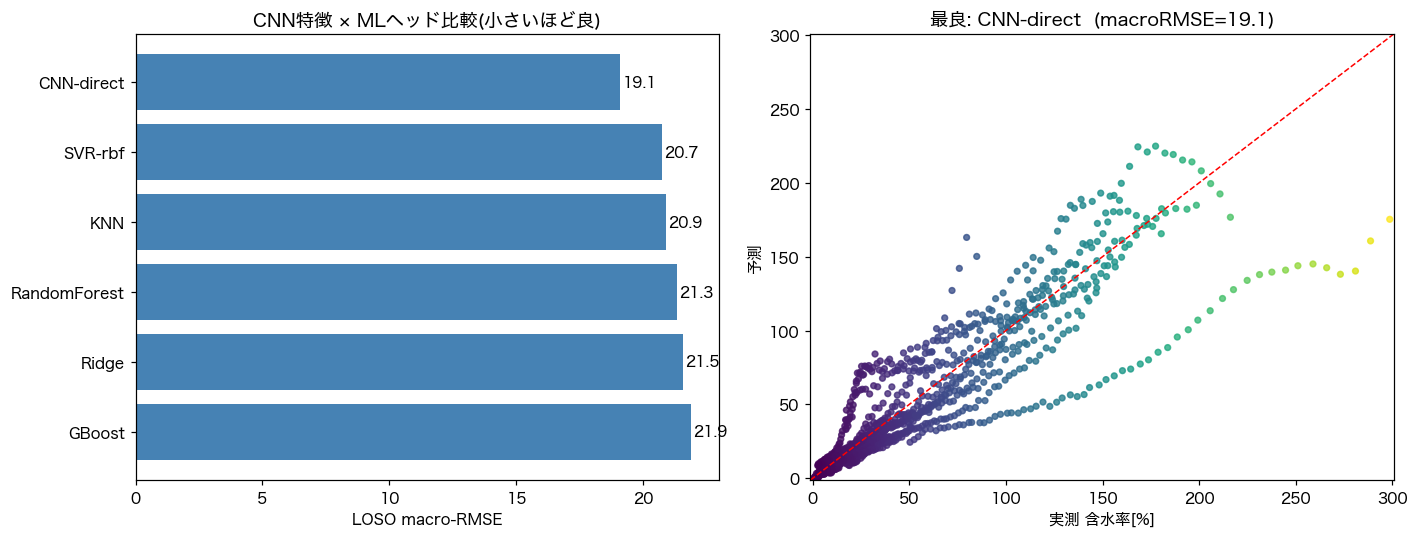

In [8]:
# モデル比較バー + 最良モデルの予測散布図
best = res.index[0]
fig, ax = plt.subplots(1,2, figsize=(13,5))
ax[0].barh(res.index[::-1], res['macroRMSE'][::-1], color='steelblue')
for i,v in enumerate(res['macroRMSE'][::-1]): ax[0].text(v+.1,i,f'{v:.1f}',va='center')
ax[0].set_xlabel('LOSO macro-RMSE'); ax[0].set_title('CNN特徴 × MLヘッド比較(小さいほど良)')
p=oof[best]
ax[1].scatter(mc,p,c=mc,cmap='viridis',s=14,alpha=.8)
lim=[mc.min()-2,mc.max()+2]; ax[1].plot(lim,lim,'r--',lw=1)
ax[1].set_xlim(lim); ax[1].set_ylim(lim); ax[1].set_xlabel('実測 含水率[%]'); ax[1].set_ylabel('予測')
ax[1].set_title(f'最良: {best}  (macroRMSE={res.loc[best,"macroRMSE"]:.1f})')
plt.tight_layout(); plt.show()

In [9]:
# 樹種別RMSE(最良モデル) — どの樹種が外挿困難か
per = pd.DataFrame({'n':[(sp==s).sum() for s in species],
                    'RMSE':[np.sqrt(((oof[best][sp==s]-mc[sp==s])**2).mean()) for s in species]},
                   index=species).sort_values('RMSE')
print(f'=== {best} 樹種別RMSE ===')
print(per.round(1))

=== CNN-direct 樹種別RMSE ===
           n  RMSE
スプルース     97   2.7
トチ       183   7.0
クリ        91   7.2
ナラ       107   9.4
ウエンジ      87  10.0
ベイマツ      93  13.2
米ヒバ       68  13.3
ヒノキ      141  15.7
チェリー      88  17.1
ウォールナット  110  19.8
ホワイトオーク   51  22.4
イチョウ      94  31.7
ベイスギ      60  78.7


## 3. 単調較正(isotonic)で折り返しを補正 — リーク無し

散布図の高含水域での **折り返し(true↑なのにpred↓)** はモデル由来の非単調性。
各 held-out 種について **他種のOOF予測で `pred→MC` の単調写像(IsotonicRegression)を学習**し、
当該種のOOF予測に適用する。held-out種自身のラベルは自分の較正に使わない=リーク無し。

In [10]:
from sklearn.isotonic import IsotonicRegression
oof_cnn = oof['CNN-direct']
oof_iso = np.zeros_like(oof_cnn)
for s in species:                       # 当該種を除く他種OOFで単調写像を学習し適用
    te = sp==s; trm = ~te
    iso = IsotonicRegression(out_of_bounds='clip').fit(oof_cnn[trm], mc[trm])
    oof_iso[te] = iso.transform(oof_cnn[te])

print('CNN-direct       macro %.2f  global %.2f' % (macro_rmse(mc,oof_cnn,sp), np.sqrt(((oof_cnn-mc)**2).mean())))
print('CNN-direct+iso   macro %.2f  global %.2f' % (macro_rmse(mc,oof_iso,sp), np.sqrt(((oof_iso-mc)**2).mean())))

per = pd.DataFrame({'n':[(sp==s).sum() for s in species],
    'CNN':[np.sqrt(((oof_cnn[sp==s]-mc[sp==s])**2).mean()) for s in species],
    'CNN+iso':[np.sqrt(((oof_iso[sp==s]-mc[sp==s])**2).mean()) for s in species]},
    index=species)
per['Δ'] = (per['CNN+iso']-per['CNN']).round(1)
print(); print(per.round(1).sort_values('CNN', ascending=False))
np.savez('/private/tmp/claude-501/-Users-haru-home-Competiton-nir-spectrum/79861ba4-31ce-4602-a572-503b136677e1/scratchpad/loso_oof.npz',
         oof_cnn=oof_cnn, oof_iso=oof_iso, mc=mc, sp=sp.astype('U16'))

CNN-direct       macro 19.10  global 22.73
CNN-direct+iso   macro 20.72  global 24.51

           n   CNN  CNN+iso    Δ
ベイスギ      60  78.7     82.8  4.1
イチョウ      94  31.7     36.6  4.9
ホワイトオーク   51  22.4     24.6  2.1
ウォールナット  110  19.8     18.6 -1.2
チェリー      88  17.1     22.9  5.8
ヒノキ      141  15.7     17.9  2.1
米ヒバ       68  13.3     12.6 -0.7
ベイマツ      93  13.2     13.2  0.0
ウエンジ      87  10.0     12.7  2.7
ナラ       107   9.4      8.6 -0.8
クリ        91   7.2      5.9 -1.4
トチ       183   7.0      7.9  1.0
スプルース     97   2.7      5.2  2.5


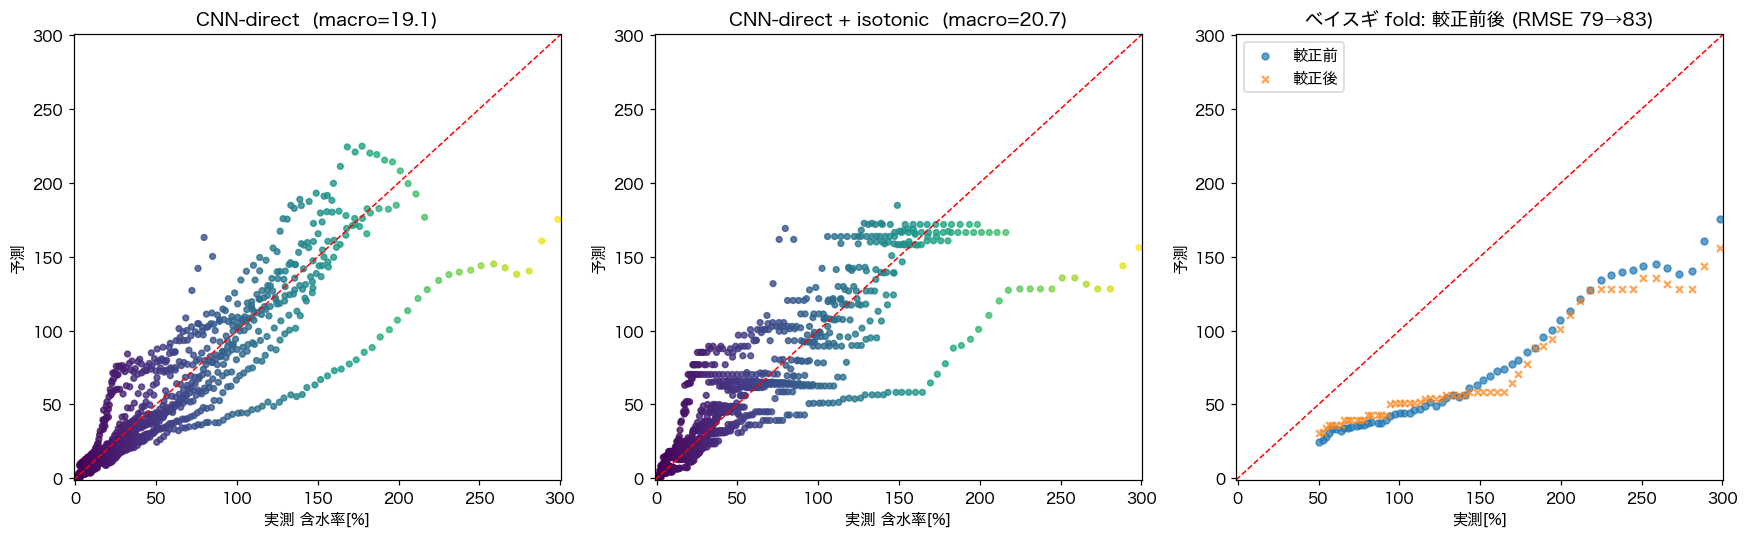

In [11]:
# 較正の効果: 予測散布図(較正前/後)と米杉foldの単調写像
fig, ax = plt.subplots(1,3, figsize=(16,5))
lim=[mc.min()-2, mc.max()+2]
for a,(p,t) in zip(ax[:2], [(oof_cnn,'CNN-direct'),(oof_iso,'CNN-direct + isotonic')]):
    a.scatter(mc,p,c=mc,cmap='viridis',s=14,alpha=.8); a.plot(lim,lim,'r--',lw=1)
    a.set_xlim(lim); a.set_ylim(lim); a.set_xlabel('実測 含水率[%]'); a.set_ylabel('予測')
    a.set_title(f'{t}  (macro={macro_rmse(mc,p,sp):.1f})')
# 米杉(ベイスギ)を例に: 較正前後で当該種の点がどう動くか
s='ベイスギ'; te=sp==s
ax[2].scatter(mc[te], oof_cnn[te], s=20, alpha=.7, label='較正前')
ax[2].scatter(mc[te], oof_iso[te], s=20, alpha=.7, label='較正後', marker='x')
ax[2].plot(lim,lim,'r--',lw=1); ax[2].set_xlim(lim); ax[2].set_ylim(lim)
ax[2].set_xlabel('実測[%]'); ax[2].set_ylabel('予測'); ax[2].legend()
ax[2].set_title(f'{s} fold: 較正前後 (RMSE {per.loc[s,"CNN"]:.0f}→{per.loc[s,"CNN+iso"]:.0f})')
plt.tight_layout(); plt.show()

## まとめ

- `fft_band_stepwise` の6帯域 × 4前処理チャネル(raw/SNV/SG1/SG2, L=738)を 1D-CNN に入力。
- CNN埋め込みの可視化で、含水率の連続グラデーション/樹種クラスタ構造を確認。
- LOSO macro-RMSE で CNN直接出力と複数MLヘッド(Ridge/RF/GBoost/SVR/KNN)を比較。
- **既知の注意**: バンドはEDAで固定(楽観側)。t-SNE/PCAの可視化は全データ学習であり性能主張には使わない。
  honestな外挿見積りはLOSOの数値を参照([[loso-validation-and-leakage]] / [[snv-epo-strength-pipeline]])。
